# Seasonal Rainfall Detrending

This notebook removes the long-term trend from seasonal rainfall training data before modeling.
It is designed for aggregated monsoon or post-monsoon rainfall such as JJAS or OND.
Each LATITUDE/LONGITUDE grid point is treated as an independent time series, so training and testing are done separately for each grid point.
The trend is fit on the training years only, subtracted before scaling, and added back after prediction.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [6]:
from dataclasses import dataclass
from typing import Optional, Tuple


@dataclass
class TrendFitResult:
    degree: int
    coefficients: np.ndarray


class SeasonalDetrendingPreprocessor:
    """Prepare sliding-window rainfall data after removing the long-term trend."""

    def __init__(
        self,
        target_column: str = "JJAS_SUM",
        lookback: int = 8,
        split_year: int = 2010,
        trend_degree: int = 1,
    ):
        self.target_column = target_column
        self.lookback = lookback
        self.split_year = split_year
        self.trend_degree = trend_degree
        self.scaler = MinMaxScaler()
        self.trend_fit: Optional[TrendFitResult] = None

    def fit_trend(self, data: pd.DataFrame) -> TrendFitResult:
        """Fit a polynomial trend to yearly mean rainfall in the training period."""

        train_data = data[data["YEAR"] <= self.split_year].copy()
        yearly_mean = (
            train_data.groupby("YEAR", as_index=True)[self.target_column]
            .mean()
            .sort_index()
        )

        if yearly_mean.empty:
            raise ValueError("No training years were found for trend fitting.")

        years = yearly_mean.index.to_numpy(dtype=float)
        values = yearly_mean.to_numpy(dtype=float)
        degree = min(self.trend_degree, len(years) - 1)
        degree = max(degree, 0)
        coefficients = np.polyfit(years, values, deg=degree)
        self.trend_fit = TrendFitResult(degree=degree, coefficients=coefficients)
        return self.trend_fit

    def trend_values(self, years):
        """Evaluate the fitted trend for one or more years."""

        if self.trend_fit is None:
            raise ValueError("Trend has not been fitted yet.")

        year_array = np.asarray(years, dtype=float)
        return np.polyval(self.trend_fit.coefficients, year_array)

    def detrend_data(self, data: pd.DataFrame) -> pd.DataFrame:
        """Add trend and detrended target columns to the data frame."""

        if self.trend_fit is None:
            self.fit_trend(data)

        result = data.copy()
        result["TREND_VALUE"] = self.trend_values(result["YEAR"].to_numpy())
        result[f"{self.target_column}_DETRENDED"] = (
            result[self.target_column] - result["TREND_VALUE"]
        )
        return result

    def prepare_train_test_data(
        self,
        data: pd.DataFrame,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
        """Create train/test sliding windows using detrended, normalized targets."""

        self.fit_trend(data)
        detrended_data = self.detrend_data(data)

        train_mask = detrended_data["YEAR"] <= self.split_year
        detrended_col = f"{self.target_column}_DETRENDED"

        self.scaler.fit(detrended_data.loc[train_mask, [detrended_col]])
        detrended_data[f"{detrended_col}_NORM"] = self.scaler.transform(
            detrended_data[[detrended_col]]
        )

        X, y, y_meta = [], [], []
        grouped = detrended_data.groupby(["LATITUDE", "LONGITUDE"])

        for _, group in grouped:
            group = group.sort_values("YEAR")
            series = group[f"{detrended_col}_NORM"].values
            years = group["YEAR"].values
            lats = group["LATITUDE"].values
            lons = group["LONGITUDE"].values
            trends = group["TREND_VALUE"].values

            if len(series) <= self.lookback:
                continue

            for i in range(len(series) - self.lookback):
                X.append(series[i : i + self.lookback])
                y.append(series[i + self.lookback])
                y_meta.append(
                    {
                        "YEAR": years[i + self.lookback],
                        "LATITUDE": lats[i + self.lookback],
                        "LONGITUDE": lons[i + self.lookback],
                        "TREND_VALUE": trends[i + self.lookback],
                    }
                )

        X = np.array(X)
        y = np.array(y)
        y_meta_df = pd.DataFrame(y_meta)

        train_indices = y_meta_df["YEAR"] <= self.split_year
        test_indices = y_meta_df["YEAR"] > self.split_year

        x_train, y_train = X[train_indices], y[train_indices]
        x_test, y_test = X[test_indices], y[test_indices]
        y_test_meta = y_meta_df[test_indices].reset_index(drop=True)

        return x_train, x_test, y_train, y_test, y_test_meta

    def inverse_transform_detrended(self, values: np.ndarray) -> np.ndarray:
        """Convert normalized detrended values back to rainfall units."""

        values = np.asarray(values).reshape(-1, 1)
        return self.scaler.inverse_transform(values).flatten()

    def restore_absolute_values(
        self,
        values: np.ndarray,
        trend_values: np.ndarray,
    ) -> np.ndarray:
        """Add trend values back to detrended predictions or targets."""

        detrended = self.inverse_transform_detrended(values)
        return detrended + np.asarray(trend_values).reshape(-1)

    def restore_from_meta(self, values: np.ndarray, meta: pd.DataFrame) -> np.ndarray:
        """Restore absolute rainfall values using the TREND_VALUE column."""

        if "TREND_VALUE" not in meta.columns:
            raise ValueError("Metadata must contain a TREND_VALUE column.")

        return self.restore_absolute_values(values, meta["TREND_VALUE"].values)

In [4]:
def plot_yearly_trend(
    data: pd.DataFrame,
    target_column: str = "JJAS_SUM",
    split_year: int = 2010,
    trend_degree: int = 1,
) -> None:
    """Plot yearly mean rainfall, the fitted trend, and the linear slope."""

    train_data = data[data["YEAR"] <= split_year].copy()
    yearly_mean = train_data.groupby("YEAR")[target_column].mean().sort_index()

    if yearly_mean.empty:
        raise ValueError("No training years were found for plotting.")

    years = yearly_mean.index.to_numpy(dtype=float)
    values = yearly_mean.to_numpy(dtype=float)

    linear_coefficients = np.polyfit(years, values, deg=1)
    linear_slope = float(linear_coefficients[0])
    linear_intercept = float(linear_coefficients[1])
    linear_fit = np.polyval(linear_coefficients, years)

    degree = min(trend_degree, len(years) - 1)
    degree = max(degree, 0)
    coefficients = np.polyfit(years, values, deg=degree)
    fitted = np.polyval(coefficients, years)

    plt.figure(figsize=(10, 5))
    plt.plot(years, values, marker="o", label="Training yearly mean")
    plt.plot(years, fitted, linestyle="--", label=f"Polynomial trend (degree {degree})")
    if degree != 1:
        plt.plot(years, linear_fit, linestyle=":", label="Linear fit used for slope")
    plt.xlabel("Year")
    plt.ylabel(f"{target_column} (mm)")
    plt.title(f"Yearly rainfall trend for {target_column}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"Linear slope for {target_column}: {linear_slope:.4f} mm/year "
        f"(intercept: {linear_intercept:.4f})"
    )


def plot_rolling_yearly_means(
    data: pd.DataFrame,
    target_column: str = "JJAS_SUM",
    split_year: int = 2010,
    windows: tuple[int, ...] = (2, 4, 5, 10),
) -> None:
    """Plot training-year rainfall smoothed with several rolling windows."""

    train_data = data[data["YEAR"] <= split_year].copy()
    yearly_mean = train_data.groupby("YEAR")[target_column].mean().sort_index()

    if yearly_mean.empty:
        raise ValueError("No training years were found for rolling-mean plotting.")

    plt.figure(figsize=(11, 5))
    plt.plot(
        yearly_mean.index,
        yearly_mean.values,
        marker="o",
        linewidth=2,
        color="black",
        label="Training yearly mean",
    )

    for window in windows:
        smoothed = yearly_mean.rolling(window=window, center=True, min_periods=window).mean()
        plt.plot(smoothed.index, smoothed.values, linewidth=2, label=f"{window}-year rolling mean")

    plt.xlabel("Year")
    plt.ylabel(f"{target_column} (mm)")
    plt.title(f"Rolling-window smoothing for {target_column}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



The example below loads the existing JJAS CSV, fits the trend from the training years only, and returns detrended train/test arrays plus metadata with the trend value for reconstruction.

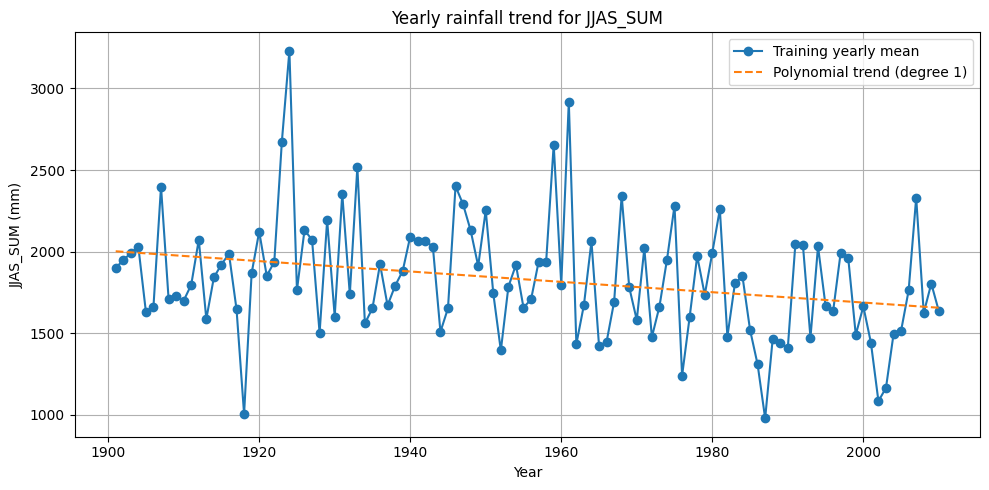

Linear slope for JJAS_SUM: -3.1716 mm/year (intercept: 8031.5797)


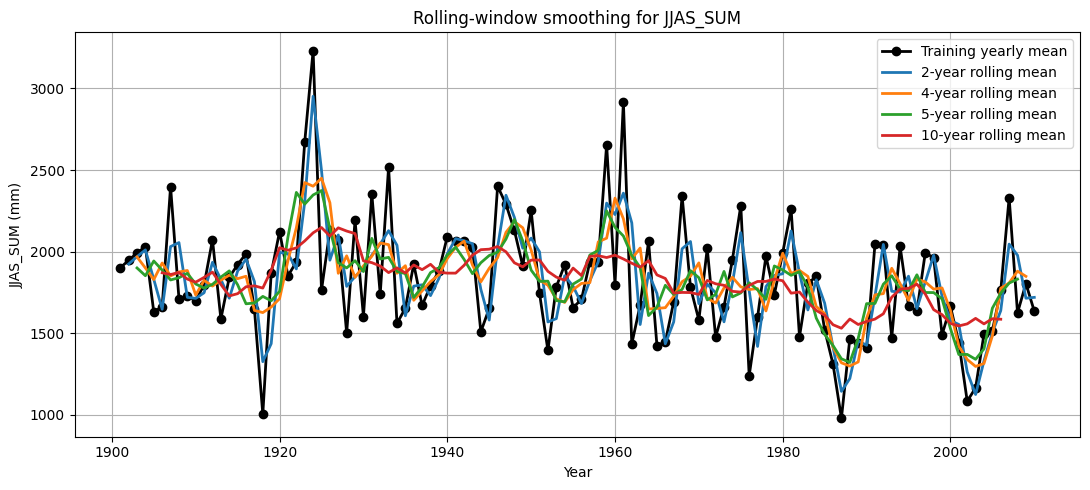

Train shape: (4692, 8) (4692,)
Test shape: (598, 8) (598,)
   YEAR  LATITUDE  LONGITUDE  TREND_VALUE
0  2011       8.5       77.0  1653.502359
1  2012       8.5       77.0  1650.330764
2  2013       8.5       77.0  1647.159170
3  2014       8.5       77.0  1643.987575
4  2015       8.5       77.0  1640.815980


In [7]:
data = pd.read_csv("data/kerala_jjas.csv")

plot_yearly_trend(
    data,
    target_column="JJAS_SUM",
    split_year=2010,
    trend_degree=1,
)

plot_rolling_yearly_means(
    data,
    target_column="JJAS_SUM",
    split_year=2010,
    windows=(2, 4, 5, 10),
)

preprocessor = SeasonalDetrendingPreprocessor(
    target_column="JJAS_SUM",
    lookback=8,
    split_year=2010,
    trend_degree=1,
)

x_train, x_test, y_train, y_test, y_test_meta = preprocessor.prepare_train_test_data(data)

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)
print(y_test_meta.head())

## OND example

The same preprocessor works for OND rainfall by changing the target column and CSV file.

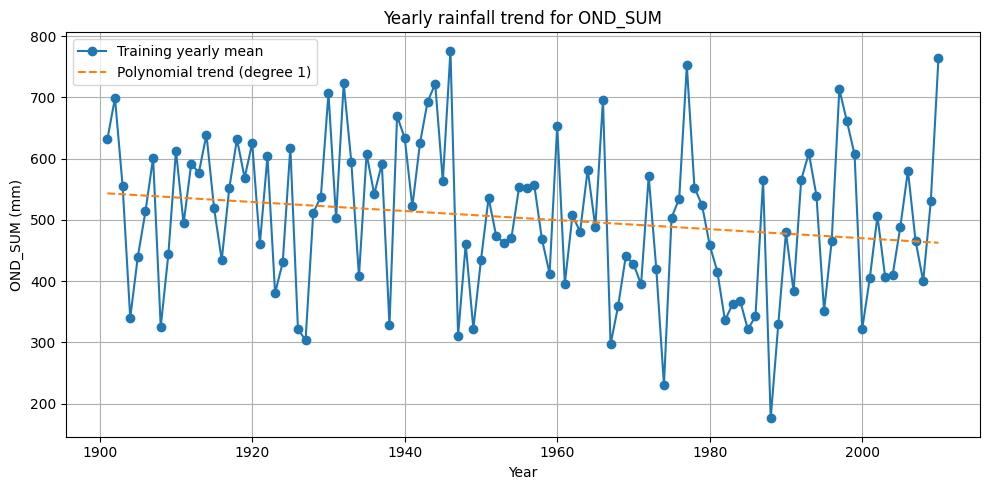

Linear slope for OND_SUM: -0.7398 mm/year (intercept: 1949.7276)


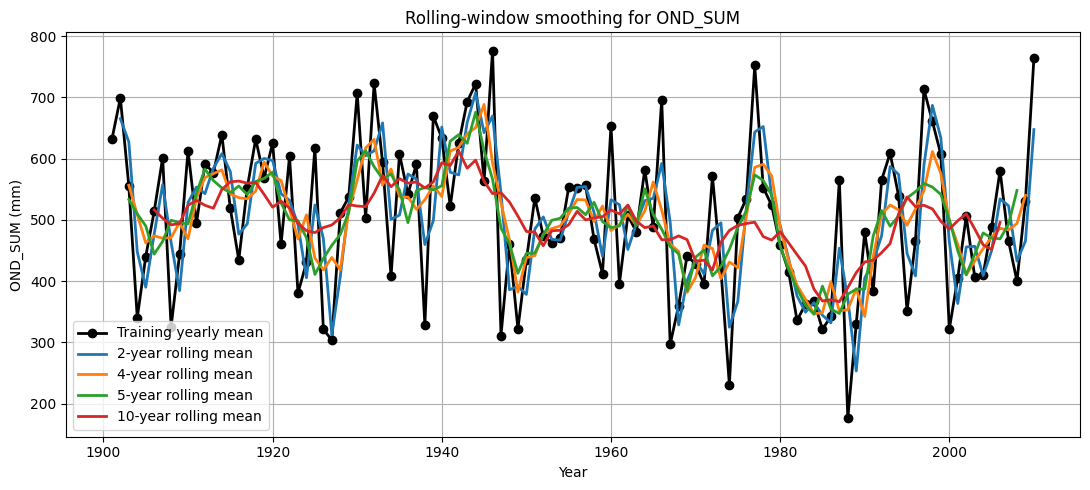

OND train shape: (4692, 8) (4692,)
OND test shape: (598, 8) (598,)
   YEAR  LATITUDE  LONGITUDE  TREND_VALUE
0  2011       8.5       77.0   461.892818
1  2012       8.5       77.0   461.152970
2  2013       8.5       77.0   460.413122
3  2014       8.5       77.0   459.673274
4  2015       8.5       77.0   458.933425


In [8]:
ond_data = pd.read_csv("data/kerala_ond.csv")

plot_yearly_trend(
    ond_data,
    target_column="OND_SUM",
    split_year=2010,
    trend_degree=1,
)

plot_rolling_yearly_means(
    ond_data,
    target_column="OND_SUM",
    split_year=2010,
    windows=(2, 4, 5, 10),
)

ond_preprocessor = SeasonalDetrendingPreprocessor(
    target_column="OND_SUM",
    lookback=8,
    split_year=2010,
    trend_degree=1,
)

ond_x_train, ond_x_test, ond_y_train, ond_y_test, ond_y_test_meta = ond_preprocessor.prepare_train_test_data(ond_data)

print("OND train shape:", ond_x_train.shape, ond_y_train.shape)
print("OND test shape:", ond_x_test.shape, ond_y_test.shape)
print(ond_y_test_meta.head())